# 01 · Wake losses in a small offshore array (Horns Rev 1 climate)

Before optimising anything, this notebook checks how much energy an 8-turbine grid loses to wakes,
first for a single wind direction and then over a full year of the site's wind climate.

**Setup:** PyWake's built-in Horns Rev 1 site (Danish North Sea), Vestas V80 2 MW turbines,
Bastankhah–Porté-Agel (2014) Gaussian wake model with wake expansion k = 0.0324555
(the value PyWake uses for this site in its own examples).

In [ ]:
%pip install -q py_wake==2.6.20 topfarm==2.6.2 pymoo==0.6.2

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from py_wake.examples.data.hornsrev1 import Hornsrev1Site, V80
from py_wake.literature.gaussian_models import Bastankhah_PorteAgel_2014

FIG = Path("figures"); FIG.mkdir(exist_ok=True)

## Site, turbine, layout and wake model

In [ ]:
site = Hornsrev1Site()
wt = V80()
D = wt.diameter()   # 80 m

# 4 x 2 grid: 4 columns ~533 m apart (6.7 D), 2 rows 400 m apart (5 D)
x = np.linspace(0, 1600, 4).repeat(2)
y = np.tile(np.linspace(0, 400, 2), 4)

wf_model = Bastankhah_PorteAgel_2014(site, wt, k=0.0324555)

## Single flow case: wind from the west at 10 m/s

With the wind along the rows, the downstream turbines sit directly in the upstream wakes.

In [10]:
sim_west = wf_model(x, y, wd=[270], ws=[10])

power_wake = sim_west.Power.sum().values / 1e6        # MW, with wakes
power_free = wt.power(10) * len(x) / 1e6               # MW, every turbine in free stream
loss_west = (1 - power_wake / power_free) * 100

print(f"Farm power with wakes:    {power_wake:.2f} MW")
print(f"Farm power without wakes: {power_free:.2f} MW")
print(f"Wake loss (this case):    {loss_west:.1f} %")

Farm power with wakes:    5.53 MW
Farm power without wakes: 10.73 MW
Wake loss (this case):    48.5 %


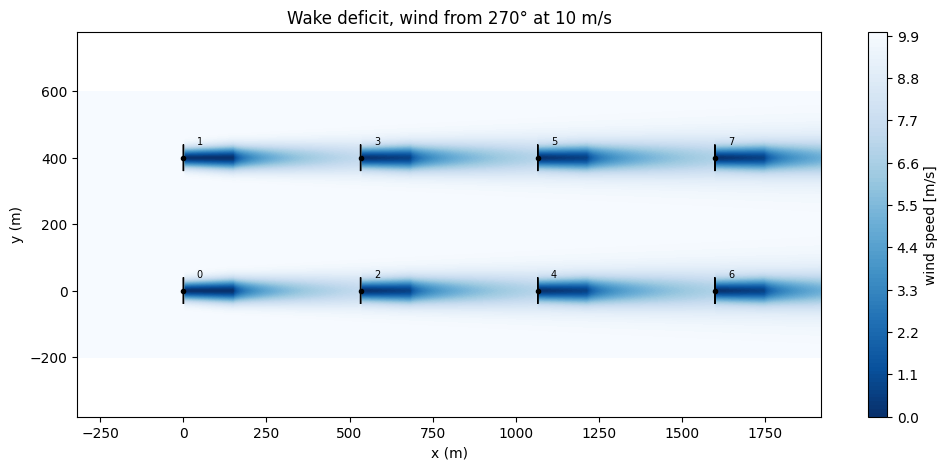

In [9]:
plt.figure(figsize=(12, 5))
sim_west.flow_map(wd=270, ws=10).plot_wake_map()
plt.title("Wake deficit, wind from 270° at 10 m/s")
plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.savefig(FIG / "01_wake_map_west.png", dpi=150, bbox_inches="tight")
plt.show()

## Full year

A single direction overstates the problem: the wind rarely blows straight down the rows.
Running every direction and wind speed bin, weighted by the site's frequencies, gives the annual figure.

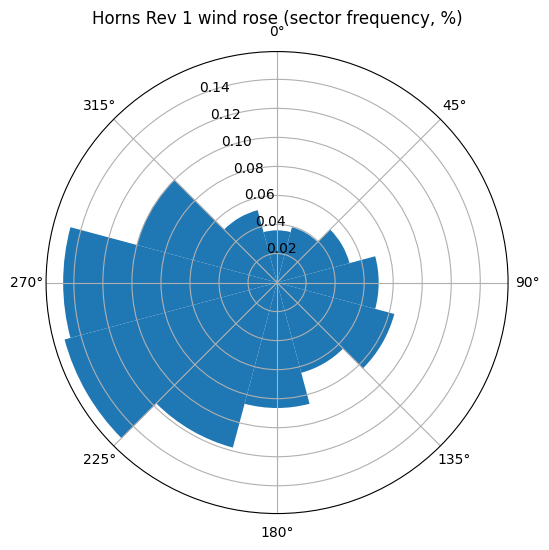

In [11]:
plt.figure(figsize=(6, 6))
site.plot_wd_distribution(n_wd=12)
plt.title("Horns Rev 1 wind rose (sector frequency, %)", pad=20)
plt.savefig(FIG / "01_wind_rose.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
sim_year = wf_model(x, y)

aep_wake = sim_year.aep().sum().values
aep_free = sim_year.aep(with_wake_loss=False).sum().values
loss_year = (1 - aep_wake / aep_free) * 100

print(f"AEP with wakes:    {aep_wake:.2f} GWh")
print(f"AEP without wakes: {aep_free:.2f} GWh")
print(f"Annual wake loss:  {loss_year:.1f} %")

AEP with wakes:    70.65 GWh
AEP without wakes: 74.40 GWh
Annual wake loss:  5.0 %


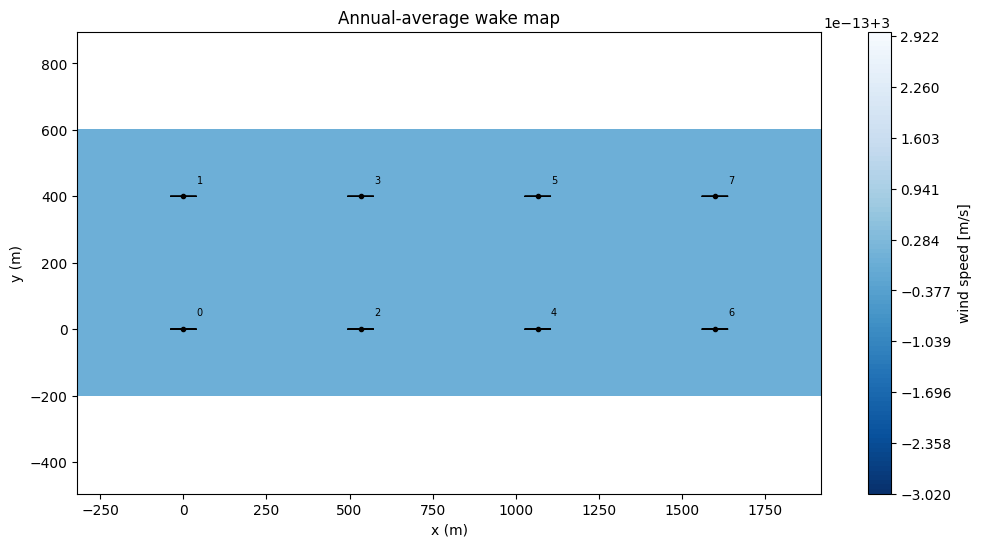

In [13]:
plt.figure(figsize=(12, 6))
sim_year.flow_map().plot_wake_map()   # no wd/ws given -> averaged over the year
plt.title("Annual-average wake map")
plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.savefig(FIG / "01_wake_map_annual.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** compare the single-direction loss with the annual loss. The gap between them is why
layout optimisation has to be done against the full wind rose, not a design wind direction.